In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

5748
9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5748 entries, 0 to 5747
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   rownames  5748 non-null   int64 
 1   tmathssk  5748 non-null   int64 
 2   treadssk  5748 non-null   int64 
 3   classk    5748 non-null   object
 4   totexpk   5748 non-null   int64 
 5   sex       5748 non-null   object
 6   freelunk  5748 non-null   object
 7   race      5748 non-null   object
 8   schidkn   5748 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 404.3+ KB
None
           rownames     tmathssk     treadssk      totexpk      schidkn
count   5748.000000  5748.000000  5748.000000  5748.000000  5748.000000
mean    5752.660404   485.648051   436.742345     9.307411    39.836639
std     3329.971901    47.771531    31.772857     5.767700    22.957552
min        2.000000   320.000000   315.000000     0.000000     1.000000
25%     2884.750000   454.000000   414.000000     5.

<Axes: >

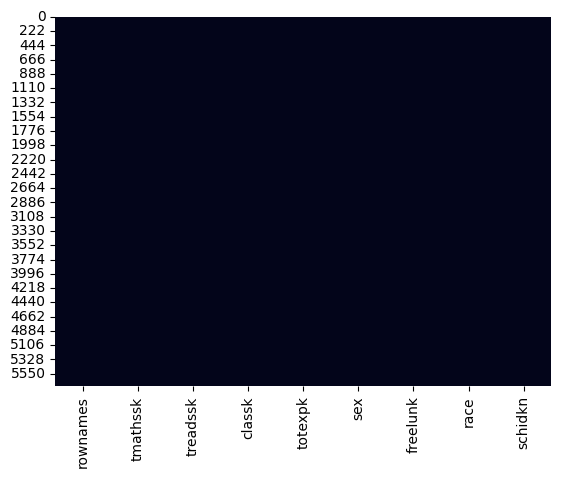

In [51]:
df = pd.read_csv('star.csv')

print(df.shape[0])
print(df.shape[1])

print(df.info())
print(df.describe())

df['totexpk'] = df['totexpk'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)
sns.heatmap(df.isnull(), cbar=False)

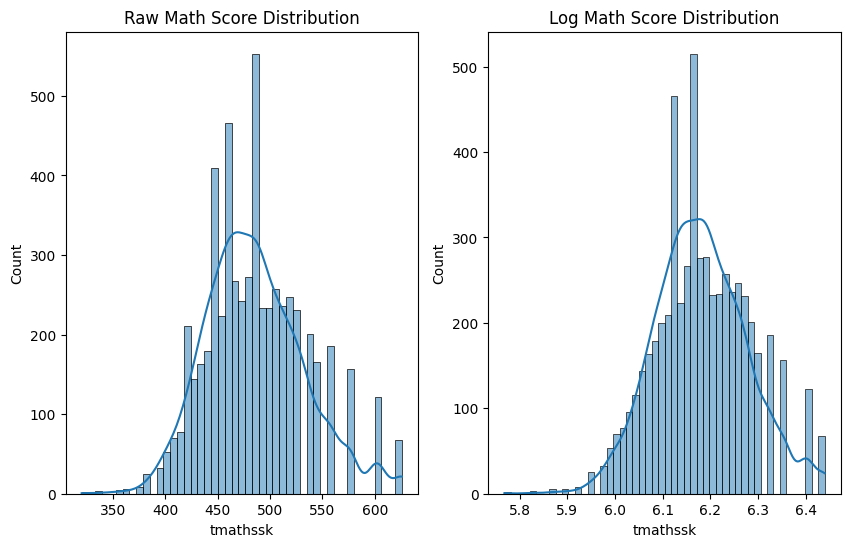

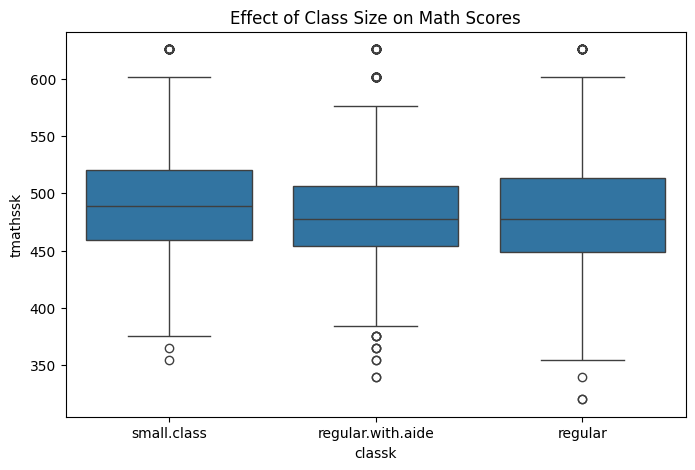

      rownames  tmathssk  treadssk             classk  totexpk   sex freelunk  \
22          48       602       456        small.class     14.0   boy      yes   
44          93       602       465        small.class     18.0   boy       no   
59         137       626       465        small.class      2.0  girl       no   
255        523       602       518            regular     12.0  girl       no   
280        566       626       510        small.class     14.0  girl       no   
...        ...       ...       ...                ...      ...   ...      ...   
5614     11312       339       390  regular.with.aide     11.0   boy      yes   
5618     11320       626       467        small.class     18.0   boy       no   
5631     11349       602       465            regular     13.0  girl       no   
5682     11449       365       391            regular      2.0   boy      yes   
5685     11458       602       492  regular.with.aide     13.0  girl       no   

       race  schidkn  
22  

In [52]:
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['tmathssk'], kde=True)
plt.title("Raw Math Score Distribution")

plt.subplot(1, 2, 2)
sns.histplot(np.log(df['tmathssk']), kde=True)
plt.title("Log Math Score Distribution")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='classk', y='tmathssk', data=df)
plt.title("Effect of Class Size on Math Scores")
plt.xlabel("classk")
plt.ylabel("tmathssk")
plt.show()

Q1 = df['tmathssk'].quantile(0.25)
Q3 = df['tmathssk'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['tmathssk'] < (Q1 - 1.5 * IQR)) | (df['tmathssk'] > (Q3 + 1.5 * IQR))]
print(outliers)

In [53]:
import statsmodels.formula.api as smf

formula_1 = 'tmathssk ~ classk + totexpk + race + sex'
model_1 = smf.ols(formula=formula_1, data=df).fit(cov_type='HC1')
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:               tmathssk   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     53.99
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           4.46e-65
Time:                        19:19:58   Log-Likelihood:                -30232.
No. Observations:                5748   AIC:                         6.048e+04
Df Residuals:                    5741   BIC:                         6.052e+04
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [54]:
formula_interact = 'tmathssk ~ classk * totexpk'
model_interact = smf.ols(formula=formula_interact, data=df).fit(cov_type='HC1')
print(model_interact.summary())

                            OLS Regression Results                            
Dep. Variable:               tmathssk   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     22.07
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           5.72e-22
Time:                        19:19:58   Log-Likelihood:                -30326.
No. Observations:                5748   AIC:                         6.066e+04
Df Residuals:                    5742   BIC:                         6.070e+04
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

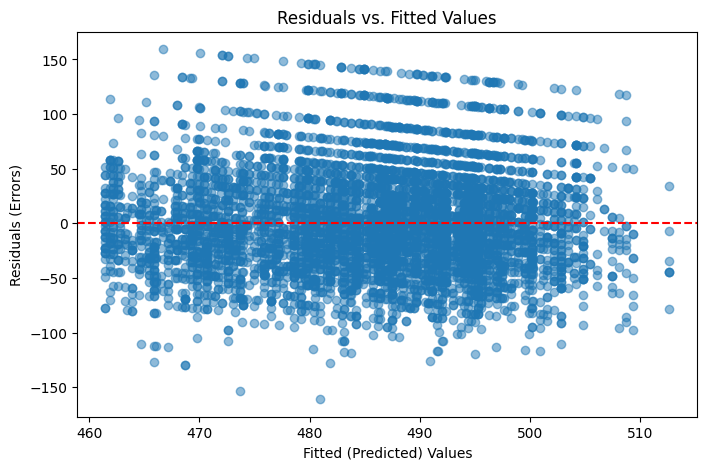

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the fitted values and residuals from your model
fitted_vals = model_1.fittedvalues
residuals = model_1.resid

# Create the scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(fitted_vals, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--') # Adds a red line at zero
plt.xlabel("Fitted (Predicted) Values")
plt.ylabel("Residuals (Errors)")
plt.title("Residuals vs. Fitted Values")
plt.show()

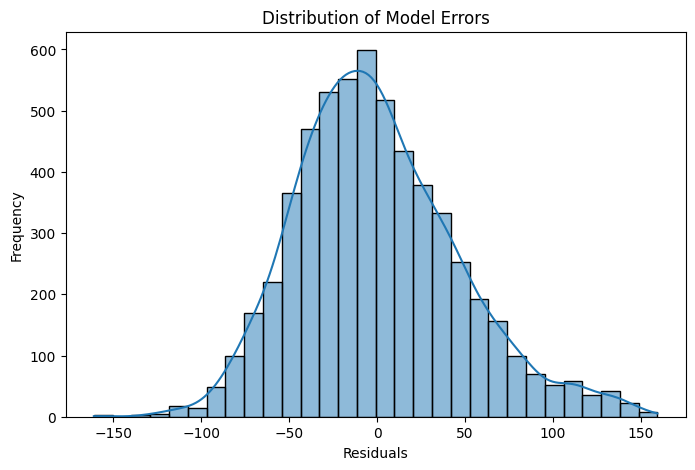

In [56]:
# Create a histogram of the residuals
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Model Errors")
plt.show()

In [57]:
print(df.groupby('classk')[['tmathssk', 'totexpk']].describe())


                  tmathssk                                                     \
                     count        mean        std    min    25%    50%    75%   
classk                                                                          
regular             2000.0  483.261000  47.500664  320.0  449.0  478.0  513.0   
regular.with.aide   2015.0  483.009926  46.111625  339.0  454.0  478.0  506.0   
small.class         1733.0  491.470283  49.468723  354.0  459.0  489.0  520.0   

                         totexpk                                            \
                     max   count      mean       std  min  25%   50%   75%   
classk                                                                       
regular            626.0  2000.0  9.078000  5.724448  0.0  4.0   9.0  13.0   
regular.with.aide  626.0  2015.0  9.807444  5.810961  0.0  5.0  10.0  13.0   
small.class        626.0  1733.0  8.990767  5.730971  0.0  4.0   8.0  13.0   

                         
                  

In [58]:
mod1 = smf.ols('tmathssk ~ classk', data=df).fit(cov_type='HC1')
print(mod1.summary())


                            OLS Regression Results                            
Dep. Variable:               tmathssk   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     17.78
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           2.01e-08
Time:                        19:19:58   Log-Likelihood:                -30361.
No. Observations:                5748   AIC:                         6.073e+04
Df Residuals:                    5745   BIC:                         6.075e+04
Df Model:                           2                                         
Covariance Type:                  HC1                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [59]:
mod2 = smf.ols('tmathssk ~ classk + totexpk + race + sex', data=df).fit(cov_type='HC1')
print(mod2.summary())

                            OLS Regression Results                            
Dep. Variable:               tmathssk   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     53.99
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           4.46e-65
Time:                        19:19:58   Log-Likelihood:                -30232.
No. Observations:                5748   AIC:                         6.048e+04
Df Residuals:                    5741   BIC:                         6.052e+04
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [60]:
mod3 = smf.ols('tmathssk ~ classk * totexpk + race + sex', data=df).fit(cov_type='HC1')
print(mod3.summary())

                            OLS Regression Results                            
Dep. Variable:               tmathssk   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     45.14
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           7.55e-71
Time:                        19:19:58   Log-Likelihood:                -30224.
No. Observations:                5748   AIC:                         6.047e+04
Df Residuals:                    5739   BIC:                         6.053e+04
Df Model:                           8                                         
Covariance Type:                  HC1                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In